In [ ]:
# Notebook setup
import sys
from pathlib import Path
base = Path.cwd()
source = next((p for p in (base, *base.parents) if (p / "code/pyproject.toml").is_file()), base / "Release-Client.zip")
if not source.exists() and "google.colab" in sys.modules:
    from google.colab import files
    print("Required file: Release-Client.zip (project code). Choose this ZIP; data files are requested next.", flush=True)
    files.upload(target_dir=str(base))
if not source.exists():
    raise FileNotFoundError("Supply Release-Client.zip, or open the extracted code/notebooks folder.")
sys.path.insert(0, str(source / "cost-aware-market-forecasting" if source.is_file() else source))
sys.modules.pop("run_zip", None)
from run_zip import prepare_reader
CODE = CODE_ROOT = prepare_reader('10_RQ2_H_indices_all_model_ensemble.ipynb', source, ())

# 10 - RQ2_H: Index all-model ensemble

## Methodology

Combine nine M15 model families separately within four Price + VIX feature sets using equal probability averaging, a 5/9 directional vote or a causal logistic meta-model. The 2024 out-of-fold probabilities initialise H1 2025; completed labels are added monthly before one of 12 candidates per index is selected. July 2025-March 2026 is descriptive replay with the selected settings fixed. USA500 and USATECH remain separate, with all-in round-trip costs of 2 and 3 bps respectively; bar-specific spreads are diagnostic, not extra deductions. The completed Q2-2026 evaluation is reported separately in Notebook 22.


In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from experiments.build_notebook_06 import MODEL_LABELS
from experiments.index_replication_protocol import MODEL_NAMES

STREAMS = ("usa500", "usatech")
ROOT = CODE_ROOT / "experiments" / "cache" / "index_all_model_ensemble"
VIX_ROOT = CODE_ROOT / "experiments" / "cache" / "index_replication"
assert len(MODEL_NAMES) == 9

def feature_label(value):
    return {
        "selected_base": "Price + VIX",
        "deberta_matched": "DeBERTa matched",
        "deepseek_matched": "LLM matched",
        "deepseek_full": "LLM full",
    }[value]

def variant_label(value):
    return {
        "soft_vote": "Equal probability average (soft vote)",
        "directional_majority": "Directional vote (5/9 majority)",
        "stack": "Causal logistic meta-model (stack)",
        "best_single": "Best single model",
    }[value]

results, selections, h1, controls, forward, vix = {}, {}, {}, {}, {}, {}
for stream in STREAMS:
    root = ROOT / stream
    results[stream] = json.loads((root / "result.json").read_text(encoding="utf-8"))
    protocol = json.loads((root / "protocol.json").read_text(encoding="utf-8"))
    manifest = json.loads((root / "manifest.json").read_text(encoding="utf-8"))
    selections[stream] = json.loads((root / "h1_selection.json").read_text(encoding="utf-8"))
    h1[stream] = pd.read_parquet(root / "h1_selected_candidates.parquet")
    controls[stream] = pd.read_parquet(root / "h1_selected_control.parquet")
    forward[stream] = pd.read_parquet(root / "forward_summary.parquet")
    vix[stream] = json.loads((VIX_ROOT / stream / "vix_admission.json").read_text(encoding="utf-8"))
    assert results[stream]["q2_loaded"] is False and protocol["q2_loaded"] is False
    assert results[stream]["selected_base"] == "price_vix"
    assert results[stream]["models_per_ensemble"] == 9
    assert len(h1[stream]) == 12 and len(controls[stream]) == 1 and len(forward[stream]) == 13
    assert selections[stream]["forward_loaded"] is False
    assert selections[stream]["selection_data_end_exclusive"] == "2025-07-01T00:00:00+00:00"
    assert manifest["protocol_hash"] == protocol["protocol_hash"] and len(manifest["artifacts"]) == 50
    assert pd.Timestamp(results[stream]["max_prediction_timestamp"]) < pd.Timestamp("2026-04-01T00:00:00Z")
    assert not forward[stream].isna().any().any()

## Ensemble construction

LogReg, Decision Tree, Random Forest, Linear SVM, XGBoost, CatBoost, MLP, LSTM and GRU each supply three-class probabilities. The four separate inputs are Price + VIX, matched DeBERTa, matched LLM and full LLM features; feature sets are not pooled.

H1 eligibility requires at least 50 trades, 15 LONG, 15 SHORT and four positive months. Selection minimises constraint shortfall before ranking by Sortino, net return, trade count, width and threshold. Acceptance also requires higher H1 net return and Sortino than the eligible single-model control while retaining at least 80% of its trades. Sharpe is reported but is not an H1 eligibility condition.


## Inherited VIX input

This table reports the earlier 2024 VIX admission results for each index, including model/fold consistency and trade retention.


In [3]:
# ensemble-vix-lineage-table
# non-economic-table
rows = []
for stream in STREAMS:
    decision = vix[stream]
    assert decision["selected_base"] == "price_vix" and decision["gate_complete"]
    rows.append({
        "Index": stream.upper(),
        "Input": "Price + VIX",
        "Positive models / 9": int(decision["metrics"]["positive_families"]),
        "Positive folds / 5": int(decision["metrics"]["positive_folds"]),
        "Median gate delta (pp)": 100 * float(decision["metrics"]["median_family_delta"]),
        "Trade retention %": 100 * float(decision["metrics"]["trade_retention"]),
    })
vix_view = pd.DataFrame(rows).sort_values(["Median gate delta (pp)", "Index"], ascending=[False, True])
display(vix_view.round({"Median gate delta (pp)": 3, "Trade retention %": 1}))
print('Both indices retain Price + VIX because the complete 2024 admission rule passed before ensemble construction.')

,Index,Input,Positive models / 9,Positive folds / 5,Median gate delta (pp),Trade retention %
1,USATECH,Price + VIX,5,4,4.366,103.0
0,USA500,Price + VIX,6,3,1.970,103.6


Both indices retain Price + VIX because the complete 2024 admission rule passed before ensemble construction.


## Ensemble membership

Each model contributes equally to voting. The logistic meta-model receives the same SHORT and LONG probabilities as separate inputs.


In [4]:
# ensemble-membership-table
# non-economic-table
members = pd.DataFrame({
    "Model": [MODEL_LABELS[name] for name in MODEL_NAMES],
    "Voting input": ["P(SHORT), P(LONG)"] * len(MODEL_NAMES),
    "Equal-vote weight %": [100 / len(MODEL_NAMES)] * len(MODEL_NAMES),
    "Stack inputs": [2] * len(MODEL_NAMES),
}).sort_values("Model")
display(members.round({"Equal-vote weight %": 1}))
print('All nine registered model families contribute to each ensemble through the same probability interface.')

,Model,Voting input,Equal-vote weight %,Stack inputs
5,CatBoost,"P(SHORT), P(LONG)",11.1,2
1,Decision Tree,"P(SHORT), P(LONG)",11.1,2
8,GRU,"P(SHORT), P(LONG)",11.1,2
7,LSTM,"P(SHORT), P(LONG)",11.1,2
3,Linear SVM,"P(SHORT), P(LONG)",11.1,2
0,LogReg,"P(SHORT), P(LONG)",11.1,2
6,MLP,"P(SHORT), P(LONG)",11.1,2
2,Random Forest,"P(SHORT), P(LONG)",11.1,2
4,XGBoost,"P(SHORT), P(LONG)",11.1,2


All nine registered model families contribute to each ensemble through the same probability interface.


## Ensemble rules

The table defines how each rule converts the same nine forecasts into one decision within a feature set.


In [5]:
# ensemble-definition-table
# non-economic-table
definitions = pd.DataFrame([
    {
        "Ensemble rule": "Equal probability average (soft vote)",
        "Base models": 9,
        "How forecasts are combined": "Mean P(SHORT), P(FLAT), P(LONG), equal weight 1/9",
        "Trained combiner": "No",
        "When result is FLAT": "Largest mean class or confidence threshold",
    },
    {
        "Ensemble rule": "Directional vote (5/9 majority)",
        "Base models": 9,
        "How forecasts are combined": "At least five agreeing LONG or SHORT class votes",
        "Trained combiner": "No",
        "When result is FLAT": "Neither direction receives five votes",
    },
    {
        "Ensemble rule": "Causal logistic meta-model (stack)",
        "Base models": 9,
        "How forecasts are combined": "18 inputs: P(SHORT) and P(LONG) from each model; P(FLAT) is implied",
        "Trained combiner": "Yes: StandardScaler + balanced L2 LogisticRegression, C=0.1, seed 42",
        "When result is FLAT": "Meta-model class or confidence threshold",
    },
])
display(definitions)
print('All nine identifies the members, while probability averaging, directional voting and the causal logistic meta-model are the three alternative combination rules.')

,Ensemble rule,Base models,How forecasts are combined,Trained combiner,When result is FLAT
0,Equal probability average (soft vote),9,"Mean P(SHORT), P(FLAT), P(LONG), equal weight 1/9",No,Largest mean class or confidence threshold
1,Directional vote (5/9 majority),9,At least five agreeing LONG or SHORT class votes,No,Neither direction receives five votes
2,Causal logistic meta-model (stack),9,18 inputs: P(SHORT) and P(LONG) from each mode...,Yes: StandardScaler + balanced L2 LogisticRegr...,Meta-model class or confidence threshold


All nine identifies the members, while probability averaging, directional voting and the causal logistic meta-model are the three alternative combination rules.


## H1 ensemble policies

These are the H1-selected settings for all 12 feature-and-rule candidates per index. Eligibility includes trade counts and monthly stability, so the largest net return alone does not determine selection.


In [6]:
# ensemble-h1-table
# economic-table
h1_view = pd.concat([
    h1[stream].assign(Index=stream.upper()) for stream in STREAMS
], ignore_index=True).rename(columns={
    "arm": "Features", "variant": "Ensemble", "width_bps": "Width bps", "tau": "Threshold",
    "trades": "Trades", "trades_per_day": "Trades/day", "n_long": "LONG", "n_short": "SHORT",
    "positive_months": "Positive months", "net_return": "Net %", "daily_sharpe": "Sharpe",
    "daily_sortino": "Sortino", "max_drawdown": "Max drawdown %",
})
h1_view["Features"] = h1_view["Features"].map(feature_label)
h1_view["Ensemble"] = h1_view["Ensemble"].map(variant_label)
h1_view["H1 status"] = h1_view["eligible"].map({True: "Eligible", False: "Below gate"})
h1_view["Net %"] *= 100; h1_view["Max drawdown %"] *= 100
h1_view = h1_view.sort_values(["Net %", "Sortino", "Sharpe"], ascending=False)
display(h1_view[["Index", "Features", "Ensemble", "Width bps", "Threshold", "H1 status", "Trades", "Trades/day", "LONG", "SHORT", "Positive months", "Net %", "Sharpe", "Sortino", "Max drawdown %"]].round(3))
eligible_count = int(h1_view["H1 status"].eq("Eligible").sum())
print(f"{eligible_count} of {len(h1_view)} feature-and-rule policies satisfy the complete H1 gate.")

,Index,Features,Ensemble,Width bps,Threshold,H1 status,Trades,Trades/day,LONG,SHORT,Positive months,Net %,Sharpe,Sortino,Max drawdown %
15,USATECH,DeBERTa matched,Equal probability average (soft vote),5,0.55,Below gate,189,1.044,110,79,3,4.611,0.679,0.339,-5.590
11,USA500,LLM full,Causal logistic meta-model (stack),10,0.55,Below gate,275,1.519,257,18,2,2.162,0.496,0.499,-3.649
18,USATECH,LLM matched,Equal probability average (soft vote),5,0.55,Eligible,189,1.044,105,84,4,2.110,0.247,0.143,-8.059
2,USA500,Price + VIX,Causal logistic meta-model (stack),5,0.50,Below gate,459,2.536,128,331,2,0.960,0.137,0.173,-10.273
0,USA500,Price + VIX,Equal probability average (soft vote),15,0.55,Below gate,491,2.713,452,39,2,0.735,0.075,0.054,-6.711
8,USA500,LLM matched,Causal logistic meta-model (stack),15,0.65,Below gate,97,0.536,36,61,2,0.257,0.140,0.088,-3.226
5,USA500,DeBERTa matched,Causal logistic meta-model (stack),10,0.55,Below gate,302,1.669,287,15,2,-1.498,-0.352,-0.294,-8.422
20,USATECH,LLM matched,Causal logistic meta-model (stack),5,0.50,Below gate,122,0.674,75,47,1,-2.620,-0.497,-0.284,-8.408
9,USA500,LLM full,Equal probability average (soft vote),5,0.55,Below gate,226,1.249,124,102,2,-3.399,-0.739,-0.328,-5.385
3,USA500,DeBERTa matched,Equal probability average (soft vote),15,0.55,Below gate,562,3.105,537,25,3,-4.136,-0.398,-0.289,-10.885


1 of 24 feature-and-rule policies satisfy the complete H1 gate.


## Frozen H1 decision against the single-model control

Within each index, compare the best constraint-ranked ensemble with the eligible single-model control. Acceptance requires higher net return and Sortino and at least 80% trade retention.


In [7]:
# ensemble-decision-table
# economic-table
rows = []
for stream in STREAMS:
    selection = selections[stream]
    winner = h1[stream][h1[stream]["candidate_id"].eq(selection["h1_winner"]["candidate_id"])].iloc[0]
    control = controls[stream].iloc[0]
    gate = selection["promotion"]
    rows.extend([
        {
            "Index": stream.upper(), "Role": "Best-ranked H1 ensemble", "Features": feature_label(winner["arm"]),
            "Policy": variant_label(winner["variant"]), "H1 status": "Eligible" if winner["eligible"] else "Below gate",
            "Downstream gate": "Accepted" if gate["promoted"] else "Not accepted", "Trades": int(winner["trades"]),
            "LONG": int(winner["n_long"]), "SHORT": int(winner["n_short"]), "Net %": 100 * float(winner["net_return"]),
            "Sharpe": float(winner["daily_sharpe"]), "Sortino": float(winner["daily_sortino"]),
            "Net delta vs control (pp)": 100 * (float(winner["net_return"]) - float(control["net_return"])),
            "Sortino delta vs control": float(winner["daily_sortino"]) - float(control["daily_sortino"]),
            "Trade retention %": 100 * float(gate["trade_retention"]),
        },
        {
            "Index": stream.upper(), "Role": "Best single-model control", "Features": feature_label(control["arm"]),
            "Policy": MODEL_LABELS[control["model_name"]], "H1 status": "Eligible" if control["eligible"] else "Below gate",
            "Downstream gate": "Reference", "Trades": int(control["trades"]), "LONG": int(control["n_long"]),
            "SHORT": int(control["n_short"]), "Net %": 100 * float(control["net_return"]),
            "Sharpe": float(control["daily_sharpe"]), "Sortino": float(control["daily_sortino"]),
            "Net delta vs control (pp)": 0.0, "Sortino delta vs control": 0.0, "Trade retention %": 100.0,
        },
    ])
decision_view = pd.DataFrame(rows).sort_values(["Net %", "Sortino", "Sharpe"], ascending=False)
display(decision_view[["Index", "Role", "Features", "Policy", "H1 status", "Downstream gate", "Trades", "LONG", "SHORT", "Net %", "Sharpe", "Sortino", "Net delta vs control (pp)", "Sortino delta vs control", "Trade retention %"]].round(3))
usa_winner = decision_view[decision_view["Index"].eq("USA500") & decision_view["Role"].eq("Best-ranked H1 ensemble")].iloc[0]
usa_control = decision_view[decision_view["Index"].eq("USA500") & decision_view["Role"].eq("Best single-model control")].iloc[0]
tech_winner = decision_view[decision_view["Index"].eq("USATECH") & decision_view["Role"].eq("Best-ranked H1 ensemble")].iloc[0]
tech_control = decision_view[decision_view["Index"].eq("USATECH") & decision_view["Role"].eq("Best single-model control")].iloc[0]
print(f"USA500 has 0/12 eligible ensembles and its best-ranked DeBERTa probability average ({usa_winner['Net %']:.2f}% Net, {usa_winner['Sortino']:.3f} Sortino) trails SVM ({usa_control['Net %']:.2f}%, {usa_control['Sortino']:.3f}), while USATECH has 1/12 eligible ensemble and its LLM matched probability average ({tech_winner['Net %']:.2f}%, {tech_winner['Sortino']:.3f}) trails LSTM ({tech_control['Net %']:.2f}%, {tech_control['Sortino']:.3f}).")

,Index,Role,Features,Policy,H1 status,Downstream gate,Trades,LONG,SHORT,Net %,Sharpe,Sortino,Net delta vs control (pp),Sortino delta vs control,Trade retention %
3,USATECH,Best single-model control,LLM matched,LSTM,Eligible,Reference,207,187,20,8.271,1.854,1.297,0.000,0.000,100.000
2,USATECH,Best-ranked H1 ensemble,LLM matched,Equal probability average (soft vote),Eligible,Not accepted,189,105,84,2.110,0.247,0.143,-6.162,-1.154,91.304
1,USA500,Best single-model control,DeBERTa matched,Linear SVM,Eligible,Reference,383,364,19,1.213,0.164,0.088,0.000,0.000,100.000
0,USA500,Best-ranked H1 ensemble,DeBERTa matched,Equal probability average (soft vote),Below gate,Not accepted,562,537,25,-4.136,-0.398,-0.289,-5.349,-0.377,146.736


USA500 has 0/12 eligible ensembles and its best-ranked DeBERTa probability average (-4.14% Net, -0.289 Sortino) trails SVM (1.21%, 0.088), while USATECH has 1/12 eligible ensemble and its LLM matched probability average (2.11%, 0.143) trails LSTM (8.27%, 1.297).


## Descriptive forward results

All 12 fixed ensemble candidates and the single-model control per index are replayed over July 2025-March 2026. This descriptive comparison includes H1-ineligible policies and zero-trade rows; it does not revise H1 selection. Zero-trade risk ratios are stored as zero, not estimated performance.


In [8]:
# ensemble-forward-table
# economic-table
forward_view = pd.concat([
    forward[stream].assign(Index=stream.upper()) for stream in STREAMS
], ignore_index=True).rename(columns={
    "arm": "Features", "variant": "Ensemble", "trades": "Trades", "trades_per_day": "Trades/day",
    "n_long": "LONG", "n_short": "SHORT", "net_return": "Net %", "daily_sharpe": "Sharpe",
    "daily_sortino": "Sortino", "max_drawdown": "Max drawdown %",
})
forward_view["Features"] = forward_view["Features"].map(feature_label)
forward_view["Ensemble"] = forward_view["Ensemble"].map(variant_label)
forward_view["Role"] = forward_view["role"].map({"ensemble": "Nine-model ensemble", "best_single_control": "Best single-model control"})
forward_view["Model"] = forward_view["model_name"].map(lambda name: "Nine base models" if name == "ALL_NINE" else MODEL_LABELS[name])
forward_view["H1 status"] = forward_view["h1_eligible"].map({True: "Eligible", False: "Below gate"})
forward_view["Forward status"] = forward_view["status"].map({"traded": "Traded", "no_trades": "No trades"})
forward_view["Net %"] *= 100; forward_view["Max drawdown %"] *= 100
numeric = ["Trades", "Trades/day", "LONG", "SHORT", "Net %", "Sharpe", "Sortino", "Max drawdown %"]
assert len(forward_view) == 26 and np.isfinite(forward_view[numeric].to_numpy(dtype=float)).all()
forward_view = forward_view.sort_values(["Net %", "Sortino", "Sharpe"], ascending=False)
display(forward_view[["Index", "Role", "Features", "Ensemble", "Model", "H1 status", "Forward status", *numeric]].round(3))
usa_forward = forward_view[forward_view["Index"].eq("USA500") & forward_view["Features"].eq("Price + VIX") & forward_view["Ensemble"].eq("Directional vote (5/9 majority)")].iloc[0]
usa_h1 = h1_view[h1_view["Index"].eq("USA500") & h1_view["Features"].eq("Price + VIX") & h1_view["Ensemble"].eq("Directional vote (5/9 majority)")].iloc[0]
tech_forward = forward_view[forward_view["Index"].eq("USATECH") & forward_view["Features"].eq("LLM full") & forward_view["Ensemble"].eq("Equal probability average (soft vote)")].iloc[0]
tech_h1 = h1_view[h1_view["Index"].eq("USATECH") & h1_view["Features"].eq("LLM full") & h1_view["Ensemble"].eq("Equal probability average (soft vote)")].iloc[0]
print(f"USA500 Price + VIX directional vote is {usa_forward['Net %']:.2f}% on descriptive forward but was H1-ineligible at {usa_h1['Net %']:.2f}%, while USATECH LLM full probability average is {tech_forward['Net %']:.2f}% but was H1-ineligible at {tech_h1['Net %']:.2f}%; these descriptive rows do not reopen H1 selection.")

,Index,Role,Features,Ensemble,Model,H1 status,Forward status,Trades,Trades/day,LONG,SHORT,Net %,Sharpe,Sortino,Max drawdown %
10,USA500,Nine-model ensemble,Price + VIX,Directional vote (5/9 majority),Nine base models,Below gate,Traded,273,0.996,177,96,2.137,0.753,0.427,-1.758
12,USA500,Nine-model ensemble,Price + VIX,Causal logistic meta-model (stack),Nine base models,Below gate,Traded,5,0.018,2,3,0.965,0.860,0.527,-0.309
18,USATECH,Nine-model ensemble,LLM full,Equal probability average (soft vote),Nine base models,Below gate,Traded,23,0.084,6,17,0.845,0.618,0.113,-1.481
15,USATECH,Nine-model ensemble,DeBERTa matched,Equal probability average (soft vote),Nine base models,Below gate,Traded,5,0.018,1,4,0.339,1.171,0.193,-0.123
13,USATECH,Best single-model control,LLM matched,Best single model,LSTM,Eligible,Traded,1,0.004,1,0,0.186,1.154,0.000,0.000
3,USA500,Nine-model ensemble,DeBERTa matched,Causal logistic meta-model (stack),Nine base models,Below gate,No trades,0,0.000,0,0,0.000,0.000,0.000,0.000
6,USA500,Nine-model ensemble,LLM full,Causal logistic meta-model (stack),Nine base models,Below gate,No trades,0,0.000,0,0,0.000,0.000,0.000,0.000
9,USA500,Nine-model ensemble,LLM matched,Causal logistic meta-model (stack),Nine base models,Below gate,No trades,0,0.000,0,0,0.000,0.000,0.000,0.000
5,USA500,Nine-model ensemble,LLM full,Equal probability average (soft vote),Nine base models,Below gate,Traded,2,0.007,2,0,-0.016,-0.155,-0.012,-0.092
4,USA500,Nine-model ensemble,LLM full,Directional vote (5/9 majority),Nine base models,Below gate,Traded,219,0.799,153,66,-0.170,-0.060,-0.030,-2.898


USA500 Price + VIX directional vote is 2.14% on descriptive forward but was H1-ineligible at -4.27%, while USATECH LLM full probability average is 0.84% but was H1-ineligible at -9.03%; these descriptive rows do not reopen H1 selection.


## Quantity-quality view

Each point represents a policy with at least one forward trade; the axes compare trade frequency with net return.


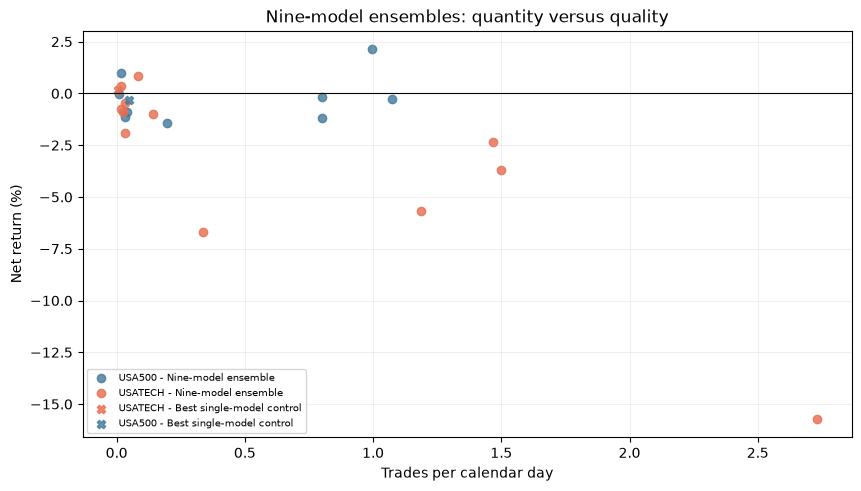

Higher trade frequency does not consistently produce higher Net across the three nine-model combination rules.


In [9]:
# economic-figure
plot_view = forward_view[forward_view["Trades"].gt(0)].copy()
colors = {"USA500": "#457b9d", "USATECH": "#e76f51"}
markers = {"Nine-model ensemble": "o", "Best single-model control": "X"}
fig, ax = plt.subplots(figsize=(8.5, 4.8), layout="constrained")
for (index, role), scope in plot_view.groupby(["Index", "Role"], sort=False):
    ax.scatter(scope["Trades/day"], scope["Net %"], color=colors[index], marker=markers[role],
               alpha=.82, label=f"{index} - {role}")
ax.axhline(0, color="black", lw=.8); ax.set_xlabel("Trades per calendar day"); ax.set_ylabel("Net return (%)")
ax.set_title("Nine-model ensembles: quantity versus quality"); ax.grid(alpha=.2); ax.legend(fontsize=7)
plt.show()
print('Higher trade frequency does not consistently produce higher Net across the three nine-model combination rules.')

## Results

No USA500 ensemble and only one USATECH ensemble meet H1 eligibility. Both best-ranked ensembles underperform their single-model controls in H1 net return and Sortino, so neither is accepted. USA500 Price + VIX directional voting later returns +2.14% across 273 descriptive forward trades, but it was H1-ineligible; this later result does not overturn selection.

Takeaway: The nine-model combinations do not meet the H1 criteria for replacing the single-model controls.
